# Map for circuit fitting

I want to find a closed curve that has derivative with constant size.

In [1]:
MAX_FOURIER_DEGREES = 100
SPATIAL_DIMENSIONS = 2

In [2]:
from typing import Literal, Optional
import collections
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm


In [3]:
class FourierFunction():

    def __init__(
        self,
        trigonometric_type: Literal["constant", "zero", "cos", "sin"],
        degree: Optional[int] = None,
        coefficient: Optional[float] = 1.0
    ):
        self.trigonometric_type = trigonometric_type
        self.degree = degree
        self.coefficient = coefficient

    @staticmethod
    def _sanitize_kwargs(kwargs):
        output = {c: kwargs[c] for c in ["trigonometric_type", "degree"]}
        output["coefficient"] = kwargs.get("coefficient", 1.0)
        if output["trigonometric_type"] in ["constant"]:
            output["degree"] = None
        elif output["trigonometric_type"] in ["zero"]:
            output["degree"] = None
            output["coefficient"] = None
        elif output["trigonometric_type"] in ["cos", "sin"]:
            if output["degree"] == 0:
                if output["trigonometric_type"] == "cos":
                    output["trigonometric_type"] = "constant"
                    output["degree"] = None
                elif output["trigonometric_type"] == "sin":
                    output["trigonometric_type"] = "zero"
                    output["degree"] = None
            elif output["degree"] < 0:
                if output["trigonometric_type"] == "cos":
                    output["degree"] *= -1
                elif output["trigonometric_type"] == "sin":
                    output["degree"] *= -1
                    output["coefficient"] *= -1
        return output


    def __mul__(self, other):
        coeff = self.coefficient * other.coefficient
        types = tuple([obj.trigonometric_type for obj in [self, other]])
        degrees = [obj.degree for obj in [self, other]]
        output = []
        if types == ("cos", "cos"):
            function_kwargs = {
                "trigonometric_type": "cos",
                "degree": degrees[0] - degrees[1],
                "coefficient": coeff * (+ 0.5)
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
            function_kwargs = {
                "trigonometric_type": "cos",
                "degree": degrees[0] + degrees[1],
                "coefficient": coeff * (+ 0.5)
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
        elif types == ("sin", "sin"):
            function_kwargs = {
                "trigonometric_type": "cos",
                "degree": degrees[0] - degrees[1],
                "coefficient": coeff * (+ 0.5)
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
            function_kwargs = {
                "trigonometric_type": "cos",
                "degree": degrees[0] + degrees[1],
                "coefficient": coeff * (- 0.5)
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
        elif types == ("sin", "cos"):
            function_kwargs = {
                "trigonometric_type": "sin",
                "degree": degrees[0] - degrees[1],
                "coefficient": coeff * (+ 0.5)
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
            function_kwargs = {
                "trigonometric_type": "sin",
                "degree": degrees[0] + degrees[1],
                "coefficient": coeff * (+ 0.5)
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
        elif types == ("cos", "sin"):
            function_kwargs = {
                "trigonometric_type": "sin",
                "degree": degrees[0] - degrees[1],
                "coefficient": coeff * (- 0.5)
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
            function_kwargs = {
                "trigonometric_type": "sin",
                "degree": degrees[0] + degrees[1],
                "coefficient": coeff * (+ 0.5)
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
        elif "zero" in types:
            pass
        elif types[0] == "constant":
            function_kwargs = {
                "trigonometric_type": types[1],
                "degree": degrees[1],
                "coefficient": coeff,
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))
        elif types[1] == "constant":
            function_kwargs = {
                "trigonometric_type": types[0],
                "degree": degrees[0],
                "coefficient": coeff,
            }
            output.append(FourierFunction(**self._sanitize_kwargs(function_kwargs)))

        return output


    def __repr__(self):
        if self.trigonometric_type in ["cos", "sin"]:
            return "Function({}, degree={}, coefficient={:.2f})".format(self.trigonometric_type, self.degree, self.coefficient)
        if self.trigonometric_type in ["constant"]:
            return "Function({}, coefficient={:.2f})".format(self.trigonometric_type, self.coefficient)
        if self.trigonometric_type in ["zero"]:
            return "Function({})".format(self.trigonometric_type)
        

In [4]:
basis_functions = [
    ((dim, deg, type_), (FourierFunction(type_, deg), dim))
    for dim in range(SPATIAL_DIMENSIONS)
    for deg in range(1, 1 + MAX_FOURIER_DEGREES)
    for type_ in ["cos", "sin"]
]

In [5]:
products_of_basis_functions = [
    ((c1, c2), (i1, i2), (bf1[0] * bf2[0]) if (bf1[1] == bf2[1]) else [])
    for c1, (i1, bf1) in enumerate(basis_functions)
    for c2, (i2, bf2) in enumerate(basis_functions)
]

In [6]:
[x for x in products_of_basis_functions if x[1]==((0, 50, 'sin'), (0, 50, 'sin'))]

[((99, 99),
  ((0, 50, 'sin'), (0, 50, 'sin')),
  [Function(constant, coefficient=0.50),
   Function(cos, degree=100, coefficient=-0.50)])]

In [7]:
[x for x in products_of_basis_functions if x[1]==((0, 50, 'cos'), (0, 50, 'cos'))]

[((98, 98),
  ((0, 50, 'cos'), (0, 50, 'cos')),
  [Function(constant, coefficient=0.50),
   Function(cos, degree=100, coefficient=0.50)])]

In [8]:
products_of_basis_functions[0]

((0, 0),
 ((0, 1, 'cos'), (0, 1, 'cos')),
 [Function(constant, coefficient=0.50),
  Function(cos, degree=2, coefficient=0.50)])

In [9]:
collections.Counter([len(x[-1]) for x in products_of_basis_functions])

Counter({2: 80000, 0: 80000})

In [10]:
split_by_degrees = {}
for index, _, bf_list in products_of_basis_functions:
    for bf in bf_list:
        if (bf.trigonometric_type == "cos"):
            key = "COS-{:04d}".format(bf.degree)
        elif (bf.trigonometric_type == "sin"):
            key = "SIN-{:04d}".format(bf.degree)
        elif (bf.trigonometric_type == "constant"):
            key = "CONSTANT"
        elif (bf.trigonometric_type == "zero"):
            key = "ZERO"
        if key not in split_by_degrees.keys():
            split_by_degrees[key] = []
        split_by_degrees[key].append((index, bf))

In [11]:
def build_matrix(function_list, matrix_size = 2 * SPATIAL_DIMENSIONS * MAX_FOURIER_DEGREES):
    matrix = np.zeros((matrix_size, matrix_size))
    for idx, func in function_list:
        matrix[idx] += func.coefficient
    return (matrix + matrix.T) / 2.0



In [12]:
[x[1] for x in split_by_degrees['COS-0001']]

[Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coefficient=0.50),
 Function(cos, degree=1, coeffic

In [13]:
null_matrices = {}
for key, val in split_by_degrees.items():
    if key.startswith("COS-") or key.startswith("SIN-"):
        null_matrices[key] = build_matrix(val)

In [14]:
norms = [np.linalg.norm(x) for x in null_matrices.values()]
print(sorted(norms)[:5])
print(sorted(norms)[-5:])

[np.float64(1.0), np.float64(1.0), np.float64(1.4142135623730951), np.float64(1.4142135623730951), np.float64(1.7320508075688772)]
[np.float64(14.0), np.float64(14.035668847618199), np.float64(14.035668847618199), np.float64(14.071247279470288), np.float64(14.071247279470288)]


In [15]:
TOLERANCE = 1e-8
def collect_eigs(matrix):
    eigs, _ = np.linalg.eig(matrix)
    return tuple(sorted([x for x in eigs if abs(x)>TOLERANCE]))


In [16]:
eigenvalues = {k: collect_eigs(v) for k, v in null_matrices.items()}

In [17]:
collections.Counter([len(x) for x in eigenvalues.values()])

Counter({384: 24,
         392: 20,
         368: 16,
         400: 14,
         396: 12,
         376: 10,
         352: 10,
         344: 10,
         360: 10,
         336: 10,
         388: 8,
         328: 8,
         364: 6,
         356: 6,
         380: 6,
         372: 6,
         348: 6,
         324: 6,
         320: 6,
         312: 6,
         304: 6,
         296: 6,
         288: 6,
         280: 6,
         272: 6,
         264: 4,
         268: 4,
         276: 4,
         284: 4,
         292: 4,
         300: 4,
         308: 4,
         316: 4,
         332: 4,
         340: 4,
         260: 2,
         256: 2,
         252: 2,
         248: 2,
         244: 2,
         240: 2,
         236: 2,
         232: 2,
         228: 2,
         224: 2,
         220: 2,
         216: 2,
         212: 2,
         208: 2,
         204: 2,
         200: 2,
         196: 2,
         192: 2,
         188: 2,
         184: 2,
         180: 2,
         176: 2,
         172: 2,
    

/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:857: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7127: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


<Axes: ylabel='Frequency'>

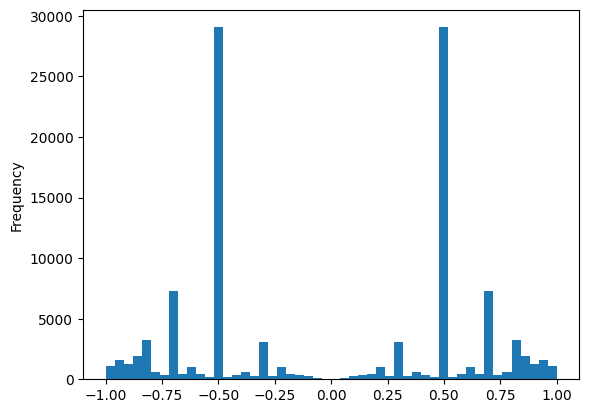

In [18]:
eigs = []
for x in eigenvalues.values():
    eigs += list(x)
pd.Series(eigs).plot.hist(bins=50)

/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:857: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7127: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


<Axes: ylabel='Frequency'>

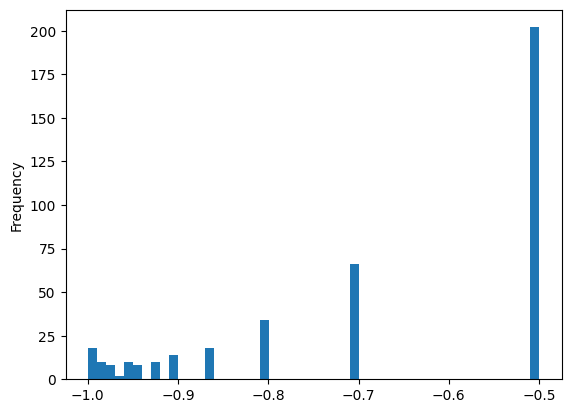

In [19]:
eigs = []
for x in eigenvalues.values():
    eigs += [min(x)]
pd.Series(eigs).plot.hist(bins=50)

/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:857: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7127: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


<Axes: ylabel='Frequency'>

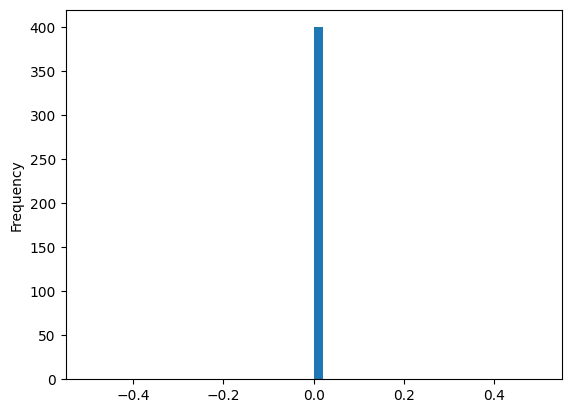

In [20]:
eigs = []
for x in eigenvalues.values():
    eigs += [sum(x).round(8)]
pd.Series(eigs).plot.hist(bins=50)

/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:857: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/tiagobbatalhao/.virtualenvs/formula_one/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7127: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


<Axes: ylabel='Frequency'>

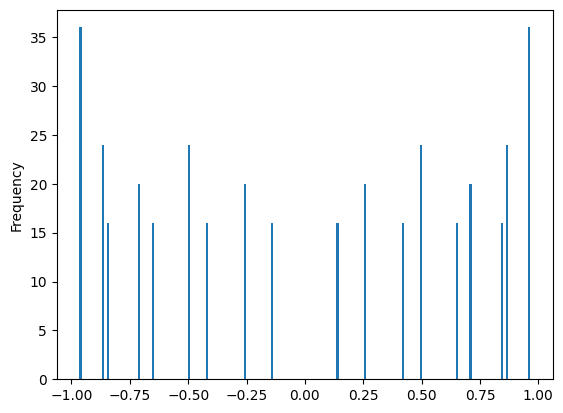

In [21]:
pd.Series(eigenvalues['COS-0019']).plot.hist(bins=200)

In [22]:
sum(eigenvalues['COS-0019']).round(8)

np.complex128(0j)

In [23]:
def matrix_commutes(mat1, mat2):
    return abs(np.linalg.norm(np.dot(mat1, mat2) - np.dot(mat2, mat1))) < 1e-8

In [24]:
nodes, edges = [], []
for k1, v1 in tqdm(null_matrices.items()):
    for k2, v2 in null_matrices.items():
        nodes += [k1, k2]
        if matrix_commutes(v1, v2):
            edges.append((k1, k2))

  0%|          | 0/400 [00:00<?, ?it/s]

In [25]:
len(set(nodes)), len(set(edges))

(400, 416)

In [26]:
import networkx as nx
gr = nx.Graph()
for nd in set(nodes):
    gr.add_node(nd)
for ed in set(edges):
    gr.add_edge(*ed)

In [27]:
components = list(nx.connected_components(gr))

In [28]:
len(components)

394

In [29]:
collections.Counter([len(x) for x in components])


Counter({1: 392, 4: 2})

In [30]:
print([x for x in components if len(x)>2])

[{'COS-0200', 'SIN-0200', 'SIN-0100', 'COS-0100'}, {'COS-0001', 'SIN-0101', 'SIN-0001', 'COS-0101'}]


In [31]:
print([x for x in components if len(x)==2])

[]


In [32]:
print([x for x in components if len(x)==1])

[{'SIN-0072'}, {'SIN-0161'}, {'SIN-0140'}, {'SIN-0034'}, {'COS-0053'}, {'SIN-0142'}, {'SIN-0097'}, {'SIN-0111'}, {'SIN-0170'}, {'COS-0014'}, {'COS-0037'}, {'SIN-0103'}, {'COS-0161'}, {'COS-0069'}, {'SIN-0158'}, {'SIN-0024'}, {'COS-0054'}, {'COS-0154'}, {'SIN-0129'}, {'SIN-0168'}, {'COS-0008'}, {'COS-0133'}, {'COS-0183'}, {'COS-0166'}, {'SIN-0009'}, {'SIN-0019'}, {'SIN-0138'}, {'SIN-0137'}, {'COS-0052'}, {'SIN-0171'}, {'COS-0104'}, {'COS-0064'}, {'SIN-0167'}, {'COS-0110'}, {'SIN-0185'}, {'SIN-0191'}, {'SIN-0146'}, {'SIN-0165'}, {'SIN-0052'}, {'SIN-0010'}, {'SIN-0043'}, {'COS-0173'}, {'COS-0162'}, {'COS-0186'}, {'SIN-0117'}, {'SIN-0157'}, {'SIN-0040'}, {'SIN-0018'}, {'COS-0126'}, {'COS-0195'}, {'COS-0136'}, {'COS-0072'}, {'COS-0034'}, {'SIN-0002'}, {'COS-0157'}, {'COS-0114'}, {'COS-0178'}, {'COS-0059'}, {'SIN-0112'}, {'COS-0096'}, {'COS-0158'}, {'COS-0152'}, {'SIN-0190'}, {'SIN-0199'}, {'SIN-0088'}, {'COS-0184'}, {'SIN-0141'}, {'SIN-0046'}, {'COS-0018'}, {'COS-0065'}, {'SIN-0023'}, {'SIN

In [33]:
print([float(x) for x in eigenvalues['COS-0100']])
print([float(x) for x in eigenvalues['SIN-0100']])
print([float(x) for x in eigenvalues['COS-0099']])
print([float(x) for x in eigenvalues['SIN-0099']])

[-0.5, -0.5, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, -0.4999999999999999, 

In [34]:
collections.Counter([len(x)%2 for x in eigenvalues.values()])

Counter({0: 400})

In [35]:
def are_eigenvalues_symmetric(eigs):
    vs = np.array(sorted(eigs)).reshape(-1)
    split = len(eigs) // 2
    v1 = vs[split:]
    v2 = vs[:split][::-1] * (-1)
    return bool(np.linalg.norm(v1 - v2).round(8) == 0)


In [36]:
collections.Counter([are_eigenvalues_symmetric(x) for x in eigenvalues.values()])

Counter({True: 400})

/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/2334579624.py:3: DeprecationWarning: The Python built-in `round` is deprecated for complex scalars, and will raise a `TypeError` in a future release. Use `np.round` or `scalar.round` instead.
  eigs += [float(round(y, 8)) for y in x ]
/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/2334579624.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  eigs += [float(round(y, 8)) for y in x ]


<Axes: ylabel='Frequency'>

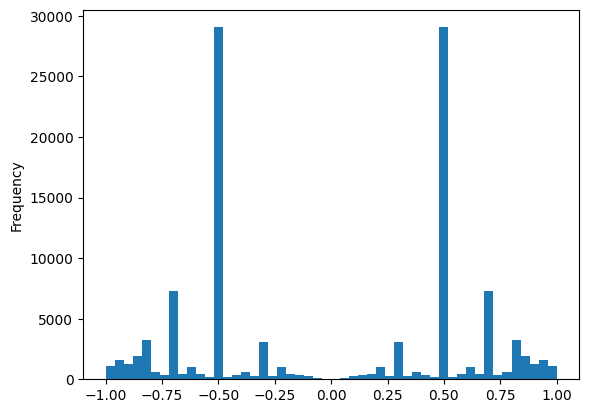

In [37]:
eigs = []
for x in eigenvalues.values():
    eigs += [float(round(y, 8)) for y in x ]
pd.Series(eigs).plot.hist(bins=50)

In [38]:
collections.Counter([len(x) for x in eigenvalues.values()]).most_common()

[(384, 24),
 (392, 20),
 (368, 16),
 (400, 14),
 (396, 12),
 (376, 10),
 (352, 10),
 (344, 10),
 (360, 10),
 (336, 10),
 (388, 8),
 (328, 8),
 (364, 6),
 (356, 6),
 (380, 6),
 (372, 6),
 (348, 6),
 (324, 6),
 (320, 6),
 (312, 6),
 (304, 6),
 (296, 6),
 (288, 6),
 (280, 6),
 (272, 6),
 (264, 4),
 (268, 4),
 (276, 4),
 (284, 4),
 (292, 4),
 (300, 4),
 (308, 4),
 (316, 4),
 (332, 4),
 (340, 4),
 (260, 2),
 (256, 2),
 (252, 2),
 (248, 2),
 (244, 2),
 (240, 2),
 (236, 2),
 (232, 2),
 (228, 2),
 (224, 2),
 (220, 2),
 (216, 2),
 (212, 2),
 (208, 2),
 (204, 2),
 (200, 2),
 (196, 2),
 (192, 2),
 (188, 2),
 (184, 2),
 (180, 2),
 (176, 2),
 (172, 2),
 (168, 2),
 (164, 2),
 (160, 2),
 (156, 2),
 (152, 2),
 (148, 2),
 (144, 2),
 (140, 2),
 (136, 2),
 (132, 2),
 (128, 2),
 (124, 2),
 (120, 2),
 (116, 2),
 (112, 2),
 (108, 2),
 (104, 2),
 (100, 2),
 (96, 2),
 (92, 2),
 (88, 2),
 (84, 2),
 (80, 2),
 (76, 2),
 (72, 2),
 (68, 2),
 (64, 2),
 (60, 2),
 (56, 2),
 (52, 2),
 (48, 2),
 (44, 2),
 (40, 2),
 (36

In [39]:
ct = collections.Counter([len(set([int(round(v*1e8)) for v in x]))  for x in eigenvalues.values()])
sorted(ct.most_common())

/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/2585803417.py:1: DeprecationWarning: The Python built-in `round` is deprecated for complex scalars, and will raise a `TypeError` in a future release. Use `np.round` or `scalar.round` instead.
  ct = collections.Counter([len(set([int(round(v*1e8)) for v in x]))  for x in eigenvalues.values()])
/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/2585803417.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  ct = collections.Counter([len(set([int(round(v*1e8)) for v in x]))  for x in eigenvalues.values()])


[(2, 204),
 (4, 64),
 (6, 34),
 (8, 18),
 (10, 14),
 (12, 12),
 (14, 8),
 (16, 4),
 (18, 4),
 (20, 2),
 (22, 4),
 (24, 2),
 (26, 2),
 (28, 2),
 (30, 4),
 (32, 2),
 (36, 2),
 (44, 2),
 (50, 2),
 (56, 2),
 (60, 2),
 (66, 4),
 (74, 2),
 (100, 2),
 (150, 2)]

In [40]:
ct = collections.Counter([
    (len(set([int(round(v*1e8)) for v in x])), len(x))
for x in eigenvalues.values()])
sorted(ct.most_common())

/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/1736229743.py:2: DeprecationWarning: The Python built-in `round` is deprecated for complex scalars, and will raise a `TypeError` in a future release. Use `np.round` or `scalar.round` instead.
  (len(set([int(round(v*1e8)) for v in x])), len(x))
/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/1736229743.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  (len(set([int(round(v*1e8)) for v in x])), len(x))


[((2, 4), 2),
 ((2, 8), 2),
 ((2, 12), 2),
 ((2, 16), 2),
 ((2, 20), 2),
 ((2, 24), 2),
 ((2, 28), 2),
 ((2, 32), 2),
 ((2, 36), 2),
 ((2, 40), 2),
 ((2, 44), 2),
 ((2, 48), 2),
 ((2, 52), 2),
 ((2, 56), 2),
 ((2, 60), 2),
 ((2, 64), 2),
 ((2, 68), 2),
 ((2, 72), 2),
 ((2, 76), 2),
 ((2, 80), 2),
 ((2, 84), 2),
 ((2, 88), 2),
 ((2, 92), 2),
 ((2, 96), 2),
 ((2, 100), 2),
 ((2, 104), 2),
 ((2, 108), 2),
 ((2, 112), 2),
 ((2, 116), 2),
 ((2, 120), 2),
 ((2, 124), 2),
 ((2, 128), 2),
 ((2, 132), 2),
 ((2, 136), 2),
 ((2, 140), 2),
 ((2, 144), 2),
 ((2, 148), 2),
 ((2, 152), 2),
 ((2, 156), 2),
 ((2, 160), 2),
 ((2, 164), 2),
 ((2, 168), 2),
 ((2, 172), 2),
 ((2, 176), 2),
 ((2, 180), 2),
 ((2, 184), 2),
 ((2, 188), 2),
 ((2, 192), 2),
 ((2, 196), 2),
 ((2, 200), 2),
 ((2, 204), 2),
 ((2, 208), 2),
 ((2, 212), 2),
 ((2, 216), 2),
 ((2, 220), 2),
 ((2, 224), 2),
 ((2, 228), 2),
 ((2, 232), 2),
 ((2, 236), 2),
 ((2, 240), 2),
 ((2, 244), 2),
 ((2, 248), 2),
 ((2, 252), 2),
 ((2, 256), 2),
 (

/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/3773850296.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  pts.append((int(k.split('-')[1]), abs(float(x))))
/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/3773850296.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  pts.append((int(k.split('-')[1]), abs(float(x))))


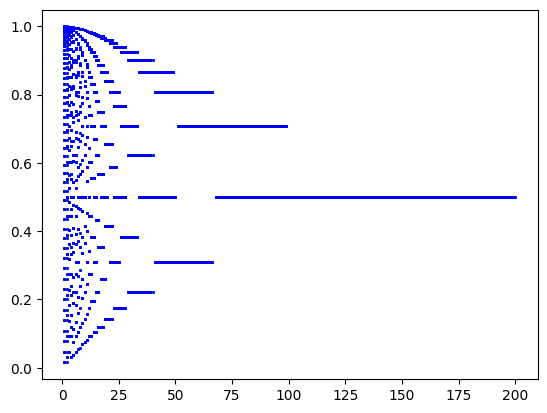

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
pts = []
for k, v in eigenvalues.items():
    if k.startswith('COS-'):
        for x in v:
            pts.append((int(k.split('-')[1]), abs(float(x))))
ax.scatter([x[0] for x in pts], [x[1] for x in pts], s=1, alpha=0.4, color='g')
pts = []
for k, v in eigenvalues.items():
    if k.startswith('SIN-'):
        for x in v:
            pts.append((int(k.split('-')[1]), abs(float(x))))
ax.scatter([x[0] for x in pts], [x[1] for x in pts], s=1, alpha=0.4, color='b')


In [60]:
sorted(set([round(x, 3) for x in eigenvalues['COS-0060']]))

/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/2909109501.py:1: DeprecationWarning: The Python built-in `round` is deprecated for complex scalars, and will raise a `TypeError` in a future release. Use `np.round` or `scalar.round` instead.
  sorted(set([round(x, 3) for x in eigenvalues['COS-0060']]))


[np.complex128(-0.809+0j),
 np.complex128(-0.707+0j),
 np.complex128(-0.309+0j),
 np.complex128(0.309+0j),
 np.complex128(0.707+0j),
 np.complex128(0.809+0j)]

In [74]:
m = null_matrices['COS-0060']
egval, egvec = np.linalg.eig(m)

In [75]:
egval[0]

np.complex128(0.7071067811865476+0j)

In [78]:
np.linalg.norm(np.dot(m, egvec[0, :]) - egval[0] * egvec[0, :])

np.float64(1.0215904139541494)

In [80]:
np.linalg.norm(np.dot(m, egvec[:, 0]) - egval[0] * egvec[:, 0])

np.float64(1.1102230246251565e-16)

In [81]:
egvec[:, 0].shape

(400,)

In [85]:
def parse_eigenvalues_and_eigenvectors(matrix):
    eigenvalues = {}
    egval, egvec = np.linalg.eig(matrix)
    for i in range(len(egval)):
        egval_r = float(round(egval[i], 8))
        if egval_r == 0:
            continue
        if egval_r not in eigenvalues.keys():
            eigenvalues[egval_r] = []
        eigenvalues[egval_r].append(egvec[:, i])
    return eigenvalues

In [87]:
parse_eigenvalues_and_eigenvectors(null_matrices['COS-0060'])

/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/3481916710.py:5: DeprecationWarning: The Python built-in `round` is deprecated for complex scalars, and will raise a `TypeError` in a future release. Use `np.round` or `scalar.round` instead.
  egval_r = float(round(egval[i], 8))
/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/3481916710.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  egval_r = float(round(egval[i], 8))


{0.70710678: [array([0.70710678+0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
         0.        +0.j, 0.        +0.j

In [89]:
parsed_egvals = {x: parse_eigenvalues_and_eigenvectors(y) for x,y in null_matrices.items()}

/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/3481916710.py:5: DeprecationWarning: The Python built-in `round` is deprecated for complex scalars, and will raise a `TypeError` in a future release. Use `np.round` or `scalar.round` instead.
  egval_r = float(round(egval[i], 8))
/var/folders/n9/qtf08bkx00z3xzx24pfblmhc0000gp/T/ipykernel_61543/3481916710.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  egval_r = float(round(egval[i], 8))


In [91]:
collections.Counter([len(x) for x in parsed_egvals.values()])

Counter({2: 204,
         4: 64,
         6: 34,
         8: 18,
         10: 14,
         12: 12,
         14: 8,
         66: 4,
         30: 4,
         22: 4,
         18: 4,
         16: 4,
         150: 2,
         100: 2,
         74: 2,
         60: 2,
         56: 2,
         50: 2,
         44: 2,
         36: 2,
         32: 2,
         28: 2,
         26: 2,
         24: 2,
         20: 2})

In [94]:
aux = []
for x in parsed_egvals.values():
    aux += [len(y) for y in x.values()]
sorted(collections.Counter(aux).most_common())

[(2, 268),
 (4, 676),
 (6, 260),
 (8, 292),
 (10, 20),
 (12, 248),
 (14, 28),
 (16, 176),
 (18, 104),
 (20, 92),
 (22, 16),
 (24, 68),
 (26, 4),
 (28, 80),
 (30, 32),
 (32, 64),
 (34, 4),
 (36, 44),
 (38, 48),
 (40, 32),
 (42, 28),
 (44, 32),
 (46, 16),
 (48, 52),
 (50, 4),
 (52, 40),
 (54, 16),
 (56, 20),
 (58, 12),
 (60, 40),
 (62, 16),
 (64, 16),
 (66, 16),
 (68, 28),
 (70, 4),
 (72, 24),
 (74, 4),
 (76, 20),
 (78, 24),
 (80, 12),
 (82, 4),
 (84, 24),
 (86, 4),
 (88, 16),
 (90, 16),
 (92, 12),
 (94, 4),
 (96, 20),
 (98, 12),
 (100, 12),
 (102, 8),
 (104, 8),
 (106, 4),
 (108, 16),
 (110, 4),
 (112, 8),
 (114, 8),
 (116, 12),
 (118, 4),
 (120, 12),
 (122, 4),
 (124, 12),
 (126, 8),
 (128, 8),
 (130, 4),
 (132, 12),
 (134, 4),
 (136, 4),
 (138, 8),
 (140, 4),
 (142, 4),
 (144, 8),
 (146, 4),
 (148, 4),
 (150, 8),
 (152, 4),
 (154, 4),
 (156, 8),
 (158, 4),
 (160, 4),
 (162, 8),
 (164, 4),
 (166, 4),
 (168, 8),
 (170, 4),
 (172, 4),
 (174, 8),
 (176, 4),
 (178, 4),
 (180, 8),
 (182, 4)